In [1]:
import torch
import torch_geometric

from torch.nn import ModuleList

from torch_geometric.data import Data
from torch_geometric.utils import grid, remove_self_loops
from torch_geometric.nn.conv import GCNConv

import matplotlib.pyplot as plt

from tueplots import bundles
from tueplots import figsizes, fontsizes, fonts

bundles.neurips2024()
figsizes.neurips2024()

{'figure.figsize': (5.5, 1.699593469062211),
 'figure.constrained_layout.use': True,
 'figure.autolayout': False,
 'savefig.bbox': 'tight',
 'savefig.pad_inches': 0.015}

In [2]:
def get_grid(size, self_loops=False):
    torch.manual_seed(0)
    # Create edge index for a 2D grid
    (row, col), pos = grid(height=size, width=size)

    if not self_loops:
        edge_index, _ = remove_self_loops(torch.stack((row,col), dim=0))
    else:
        edge_index, _ = remove_self_loops(torch.stack((row,col), dim=0))
    
    # Total number of nodes
    num_nodes = size*size
    
    # (Optional) Create dummy node features
    x = torch.ones((num_nodes,1), requires_grad=True)
    
    # Create the graph data object
    data = Data(x=x, edge_index=edge_index)
    return data

In [3]:
class LinearGCN(torch.nn.Module):

    def __init__(self, dim_input, dim_emb, num_layers):
        super().__init__()
        self.num_layers = num_layers
        layers = []
        for l in range(num_layers):
            layers.append(GCNConv(dim_input if l == 0 else dim_emb, dim_emb, add_self_loops=False, normalize=True))

        self.layers = ModuleList(layers)

    def forward(self, x, edge_index):
        for l in range(self.num_layers):
            h = self.layers[l](x if l == 0 else h, edge_index)

            h.retain_grad()
        return h

In [4]:
import ray
import pandas as pd
import torch
from itertools import product

# Initialize Ray
ray.init(ignore_reinit_error=True)

# Assuming get_grid and LinearGCN are already defined
size = 10
g = get_grid(size=size, self_loops=False)

edge_index = g.edge_index
x = g.x

param_grid = list(product(
    [1]+list(range(10, 510, 10)),
    [8, 32, 64, 128],
    list(range(5))
))


@ray.remote(
    num_cpus=1,
    num_gpus=0,
    max_calls=1,
    # max_calls=1 --> the worker automatically exits after executing the task
    # (thereby releasing the GPU resources).
)
def compute_jacobian(args):
    num_layers, dim_emb, edge_index, run_id, x = args
    model = LinearGCN(dim_input=1, dim_emb=dim_emb, num_layers=num_layers)
    def func(x_input):
        return model(x_input, edge_index)

    try:
        out = torch.autograd.functional.jacobian(func, x)
        mean_val = torch.norm(out, p=1).item()
        shape = tuple(out.shape)
    except Exception as e:
        mean_val = None
        shape = str(e)

    return {
        'num_layers': str(num_layers),
        'size of node embedding': str(dim_emb),
        'jacobian_shape': str(shape),
        'jacobian_mean': mean_val,
        'run_id': run_id
    }

# Launch Ray tasks
futures = [
    compute_jacobian.remote((num_layers, dim_emb, edge_index, run_id, x))
    for num_layers, dim_emb, run_id in param_grid
]

# Collect results
results = ray.get(futures)
df = pd.DataFrame(results)

2025-04-28 12:27:24,155	INFO worker.py:1783 -- Started a local Ray instance.


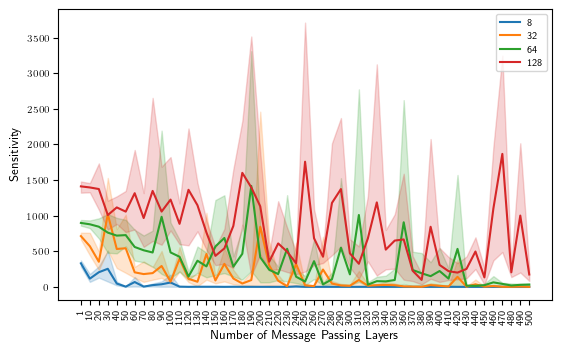

In [5]:
import seaborn as sns
with plt.rc_context(bundles.neurips2024()):
    sns.lineplot(data=df, x='num_layers',  y='jacobian_mean', hue='size of node embedding')
    plt.xlabel('Number of Message Passing Layers')
    plt.ylabel('Sensitivity')
    legend = plt.legend(loc='upper right')
    for text in legend.get_texts():
        text.set_ha('right')  # Right-align each legend text

    # rotate x-axis labels
    plt.xticks(rotation=90)
    

    plt.savefig('figs/grid_sensitivity.pdf')